## 1 概述

在机器学习领域，缩写 LR 通常指逻辑回归（Logistic Regression），而非线性回归（Linear Regression），这是因为逻辑回归在分类任务中的应用极为广泛，且是神经网络的基石。

逻辑回归，虽然名字里带着“回归”，但实际上是一种分类算法，其核心思想是：在多元线性回归（MLR）的基础上，将输出值通过一个 Sigmoid 函数（也称逻辑函数）压缩到 0 到 1 之间，从而将其解释为“属于某一类别的概率”。

## 2 Sigmoid 函数

在 MLR 中，假设函数是：$\hat{Y} = XW$ ，这个 $\hat{Y}$ 的取值范围是 $(-\infty, +\infty)$ ，如果拿它去做分类，会遇到两个问题：

1. 没有概率意义：分类问题要求输出是“属于某一类的概率”，必须在 0 到 1 之间。
2. 对异常值过于敏感：因为代价函数是均方误差 MSE ，如果某个异常样本的 $\hat{Y}$ 很大，它会严重扭曲模型。

因此，我们需要一个函数，能把任意实数 $\hat{Y}$ 压缩到 0 和 1 之间，它就是 Sigmoid 函数：$\sigma(z) = \frac{1}{1 + e^{-z}}$ ，其中 $z$ 就表示 $\hat{Y}$ 。


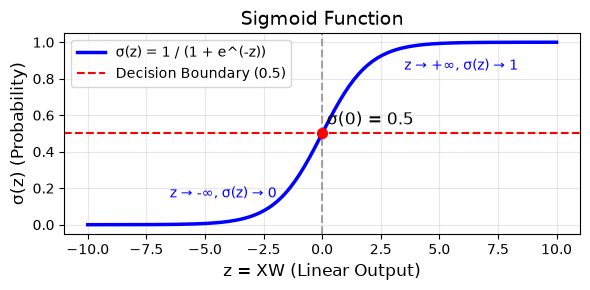

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)
y = sigmoid(z)
plt.figure(figsize=(6, 3))
plt.plot(z, y, color='blue', linewidth=2.5, label='σ(z) = 1 / (1 + e^(-z))')
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Decision Boundary (0.5)')
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
plt.scatter([0], [0.5], color='red', s=50, zorder=5)
plt.text(0.2, 0.55, 'σ(0) = 0.5', fontsize=12)
plt.text(3.5, 0.85, 'z → +∞, σ(z) → 1', fontsize=10, color='blue')
plt.text(-6.5, 0.15, 'z → -∞, σ(z) → 0', fontsize=10, color='blue')
plt.xlabel('z = XW (Linear Output)', fontsize=12)
plt.ylabel('σ(z) (Probability)', fontsize=12)
plt.title('Sigmoid Function', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

1. 从图中可以看到，Sigmoid 函数将线性输出 $z$ 平滑地映射到 (0, 1) 区间
    - 当 $z \to +\infty$ 时，$\sigma(z) \to 1$。
    - 当 $z \to -\infty$ 时，$\sigma(z) \to 0$。
2. 当 $z = 0$ 时，$\sigma(0) = 0.5$（这是分类的天然分界线）。
3. $\sigma(z)$ 单调递增且处处可导（这对梯度下降求导至关重要）。

## 3 假设函数

将 MLR 的线性部分 $z=XW$ 代入 Sigmoid 函数，就得到了逻辑回归的假设函数：

$$
\hat{y} = \sigma(XW) = \frac{1}{1 + e^{-XW}}
$$

在逻辑回归中，虽然通常也把 $\hat{y}$ 叫做预测值，但严格来说是“预测为正类的概率”，即 $\hat{y} = P(y=1 \mid X)$ 。
- 如果 $\hat{y} \ge 0.5$ ，预测为正类（1）。
- 如果 $\hat{y} < 0.5$ ，预测为负类（0）。

> 逻辑回归的本质是“线性回归 + Sigmoid 函数”。

## 4 梯度消失

Sigmoid 函数 $\sigma(z) = \frac{1}{1 + e^{-z}}$ 有一个常用的导数公式：$\sigma^{'}(z)=\sigma(z)(1-\sigma(z))$ ，其推导过程如下：
$$
\frac{\partial\sigma}{\partial z}=\frac{e^{-z}}{(1+e^{-z})^2}=\frac{1}{1+e^{-z}}\cdot\frac{e^{-z}}{1+e^{-z}}=\frac{1}{1+e^{-z}}\cdot(1-\frac{1}{1+e^{-z}})=\sigma(z)(1-\sigma(z))
$$

会出现什么问题呢：
1. 当 $z=0$ ，$\sigma(z)=\frac{1}{2}$ ，导数 $=\frac{1}{2}\cdot\frac{1}{2}=0.25$
1. 当 $z$ 较大（比如 $z=10$ ），$\sigma(z)\approx 1$ ，导数 $\approx 1\times 0=0$
1. 当 $z$ 较小（比如 $z=-10$ ），$\sigma(z)\approx 0$ ，导数 $\approx 0\times 1=0$

也就是说，$\sigma^{'}(z)$ 最大值是 0.25 ，然后 $|z|$ 只要稍大就会使 $\sigma^{'}(z)$ 趋近于 0 。

若继续使用线性回归的 MSE 作为代价函数：$J(W)=(Y-\sigma(z))^2$ ，那么梯度的计算：$\frac{\partial J}{\partial W}=(Y-\sigma(z))\cdot\sigma^{'}(z)\cdot X$
> 因为 $z=XW$ ，所以这里最后还有一个 $X$

所以，当预测出现偏差，$z$ 较大或较小，都容易导致 $\sigma^{'}(z)\approx 0$ ，进而使梯度 $\frac{\partial J}{\partial W}\approx 0$ ，梯度下降就“降不动了”，这就是梯度消失。

## 5 交叉熵

交叉熵是信息论、统计学与机器学习三条知识线交汇的产物，下面是基本的科普：
1. 1865 年，克劳修斯提出热力学熵，熵=无序程度。
1. 1877 年，玻尔兹曼提出统计熵，熵=微观状态数的对数。
1. 1920 年代，费希尔推广最大似然估计，成为统计推断的基石。
1. 1948 年，香农发表《通信的数学理论》，信息论诞生：
    - 信息量：一个事件发生的概率越低，包含的信息量越大。换句话说就是，越混乱的局面，越需要更多的描述。
    - 信息熵：一条信息的平均不确定性。即：编码该信息所需的最少平均比特数。
1. 1951 年，库尔巴克与莱布勒提出KL散度，量化两个分布的差异。
1. 1986 年，Rumelhart 等人推广反向传播，交叉熵成为神经网络分类任务的标准。

现实世界充满不确定性（热力学熵）$\to$ 香农将其数学化为“信息量”（信息熵）$\to$ 当我们用预测的模型去描述现实时，多花的“编码成本”就是交叉熵 $\to$ 而最小化这个成本，等价于统计学中的最大似然估计 $\to$ 最终，这一思想在神经网络的反向传播中被验证为最优选择。

假设有两个离散的概率分布：
1. 真实分布 P（表示正确答案）
1. 预测分布 Q（表示模型猜的）

一个事件 $x$ 发生后，它包含的信息量：$I(x)=-\log P(x)$ ，其中 $P(x)$ 表示事件发生的概率。

真实分布的平均不确定性，即信息熵：$H(P)=-\sum P(x)\log P(x)$

用 Q 近似 P 时损失的信息量，即 KL 散度：
$$
D_{KL}(P\parallel Q)=\sum P(x)\log\frac{P(x)}{Q(x)}=\sum P(x)\log P(x)-\sum P(x)\log Q(x)=-H(P)-\sum P(x)\log Q(x) \\
\Downarrow \\
H(P)+D_{KL}(P\parallel Q)=-\sum P(x)\log Q(x)
$$

这就是交叉熵的定义：交叉熵 = 真实分布的不确定性（信息熵）+ 用预测分布描述真实分布需要的额外代价（KL散度），即：
$$
H(P,Q)=H(P) + D_{KL}(P\parallel Q)=-\sum P(x)\log Q(x)
$$

## 6 代价函数

已知交叉熵：$H(P,Q)=-\sum P(x)\log Q(x)$ ，如何推导出代价函数？

先看看怎么用这个交叉熵公式，假设一个事件 $x$ 有正、负两个可能结果，那么：
$$
H(P,Q)=-\sum_{x=正,负}P(x)\log Q(x)=-[P(正)\log Q(正)+P(负)\log Q(负)]
$$
若 $x$ 真实为正，预测为正的概率是 0.8 ，那么：
$$
P(正)=1,\,P(负)=0 \\
Q(正)=0.8,\,Q(负)=0.2
$$
因此：
$$
-[P(正)\log Q(正)+P(负)\log Q(负)]=-\log 0.8=-\log Q(正)
$$
反之，若 $x$ 真实为负，预测为正的概率是 0.2 ，那么：
$$
P(正)=0,\,P(负)=1 \\
Q(正)=0.2,\,Q(负)=0.8 \\
-[P(正)\log Q(正)+P(负)\log Q(负)]=-\log 0.2=-\log Q(负)
$$
这是一个“开关”的规律，用 $y$ 表示真实为正的概率，用 $\hat{y}$ 表示预测为正的概率，那么这个规律是：
- 若真实为正，即 $y=1,\,1-y=0$ ，则交叉熵 $H=-\log\hat{y}$
- 若真实为负，即 $y=0,\,1-y=1$ ，则交叉熵 $H=-\log(1-\hat{y})$

合并起来就是：$H=-[y\log\hat{y}+(1-y)\log(1-\hat{y})]$ ，这就是损失函数。

那么代价函数就是扩展到整个数据集：
$$
J(W)=-\frac{1}{n}\sum_{i=1}^n[y\log\hat{y}+(1-y)\log(1-\hat{y})]
$$

## 7 计算梯度

> 注：在信息论中 $\log$ 通常是以 2 为底，因为要计算比特；但在机器学习中，通常以自然对数 e 为底，即 $\ln$ ，因为在不影响结果的情况下求导更简单

现在有了三个关键的函数：
1. 线性部分：$z=XW$
1. Sigmoid 函数：$\hat{y}=\frac{1}{1+e^{-z}}$
1. 损失函数：$L=-[y\ln\hat{y}+(1-y)\ln(1-\hat{y})]$

要求的是：$\frac{\partial L}{\partial W}=\frac{\partial L}{\partial \hat{y}}\cdot\frac{\partial \hat{y}}{\partial z}\cdot\frac{\partial z}{\partial W}$

先算：$\frac{\partial L}{\partial \hat{y}}=-\frac{y}{\hat{y}}+\frac{1-y}{1-\hat{y}}$

然后，$\frac{\partial \hat{y}}{\partial z}$ 是 Sigmoid 函数的求导，前面有推导：$\frac{\partial \hat{y}}{\partial z}=\hat{y}(1-\hat{y})$

最后：$\frac{\partial z}{\partial W}=X$

先处理前两项，合并及化简：
$$
(-\frac{y}{\hat{y}}+\frac{1-y}{1-\hat{y}})\cdot\hat{y}(1-\hat{y})=-y(1-\hat{y})+(1-y)\hat{y}=\hat{y}-y
$$
把第三项也带上，可得：$\frac{\partial L}{\partial W}=(\hat{y}-y)\cdot X$

上述推导用的 $X$ 都是指单个样本的所有特征的取值所组成的行向量，即 $X_{1\times m}$ ，而 $\hat{y}-y$ 是一个数，为了得到的结果与权重 $W_{m\times 1}$ 一致，且为了匹配全部样本的代价函数中的矩阵乘法，所以这里通常写成：
$$
\frac{\partial L}{\partial W}=X^T\cdot(\hat{y}-y)
$$

扩展到整个数据集，可得代价函数的导函数，注意此处的 $X$ 是全部样本的所有特征的取值所组成的矩阵 $X_{n\times m}$ ：
$$
dW=\frac{\partial J}{\partial W}=\frac{1}{n}X^T(\hat{Y}-Y)
$$

嗯？这怎么跟 MLR 中的 $dW$ 一样呢？是的，就是一样，唯一的区别是 $\hat{Y}$ 的内容：
- MLR : $\hat{Y}=XW$
- LR : $\hat{Y}=Sigmoid(XW)=\frac{1}{1+e^{-XW}}$

为什么梯度公式没变？因为交叉熵天生就是为 Sigmoid 函数设计的“反函数”，其“信息论结构”恰好抵消了 Sigmoid 函数在两端平坦导致的梯度消失，使得误差 $\hat{y}-y$ 依然能直接驱动权重更新。

绕了一大圈，其实只需要把 $\hat{Y}=\frac{1}{1+e^{-z}}\,,\,z=XW$ 代入 MLR 中的梯度公式 $dW=\frac{\partial J}{\partial W}=\frac{1}{n}X^T(\hat{Y}-Y)$ 即可，但理解了背后逻辑，也算是深入浅出了。

无论是线性回归还是逻辑回归，梯度下降更新权重的驱动力都是预测误差 $\hat{y}-y$ 。误差越大，梯度越大，梯度下降越快。区别仅在于“如何得到预测值”——线性回归直接输出，逻辑回归通过 Sigmoid 挤压后输出。

## 8 数据集

继续用鲍鱼数据集 (Abalone Dataset)，但要进行阈值化，通过 Rings 分成成年与未成年两类：
- Rings >= 10 $\to$ Adult = 1
- Rings < 10 $\to$ Adult = 0


In [3]:
import pandas as pd
import os

names = ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']
df = pd.read_csv('./datasets/abalone/abalone.data', header=None, names=names)
out_dir = './outputs/lr'
os.makedirs(out_dir, exist_ok=True)
df['Adult'] = (df['Rings'] >= 10).astype(int)
print(df['Adult'].value_counts())
df.to_csv(f'{out_dir}/abalone_processed.csv', index=False)
# 打乱数据（frac=1 表示抽取 100% 的行，random_state=42 设置随机种子保证结果可复现）
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
# 计算切分位置
split_idx = int(len(df_shuffled) * 0.8)
# 按位置切分
df_train = df_shuffled.iloc[:split_idx]
df_test = df_shuffled.iloc[split_idx:]
# 保存切分好的训练集和测试集
df_train.to_csv(f'{out_dir}/abalone_train.csv', index=False)
df_test.to_csv(f'{out_dir}/abalone_test.csv', index=False)

Adult
0    2096
1    2081
Name: count, dtype: int64


## 9 评估指标

介绍评估指标前，需要先弄清楚四个基础概念（混淆矩阵的四个象限）：
- TP（True Positive，真阳性）：真实是正类，预测也是正类。
- TN（True Negative，真阴性）：真实是负类，预测也是负类。
- FP（False Positive，假阳性）：真实是负类，预测是正类。
- FN（False Negative，假阴性）：真实是正类，预测是负类。

在分类问题中，评估指标不再看“误差有多大”，而是看“猜对的比例有多高”。下面是分类算法中最常用的四个评估指标：

1. 准确率（Accuracy）：计算公式 $\frac{TP+TN}{TP+TN+FP+FN}$ ，表示所有预测中猜对的比例。这是最直观的指标，适合在类别均衡时使用。

1. 精确率（Precision）：计算公式 $\frac{TP}{TP+FP}$ ，表示被预测为“正类”的样本中，实际真的是正类的比例。

1. 召回率（Recall）：计算公式 $\frac{TP}{TP+FN}$ ，表示所有真正的“正类”样本中，被模型成功找出来的比例。

1. F1-score ：计算公式 $2 \times \frac{Precision \times Recall}{Precision + Recall}$ ，精确率和召回率的调和平均。当需要同时兼顾精确率和召回率时，F1 能给出一个综合的平衡评价。

> 混淆矩阵（Confusion Matrix）是理解上述四个指标的基础工具。它把预测结果和真实结果交叉列成 2×2 的表格，可以直观地看出模型在哪类样本上犯错更多。

类别均衡时，优先看准确率。  
类别不均衡时，需要结合精确率和召回率一起看。  
如果要选一个综合指标，看 F1-score 。  
混淆矩阵能帮你快速定位模型的具体错误类型。  

## 10 手写代码

无论是线性回归还是逻辑回归，梯度下降更新权重的驱动力都是预测误差 $\hat{y}-y$ 。误差越大，梯度越大，梯度下降越快。区别仅在于“如何得到预测值”——线性回归直接输出，逻辑回归通过 Sigmoid 挤压后输出。


✅ 停止于代价变化容差：第 34401 轮，代价变化 = 1.00e-07 < 1e-07

训练完成，拟合方程系数：
  bias (intercept) : 0.097310
  Length               : -0.453306
  Diameter             : 0.504351
  Height               : 0.361404
  Whole_weight         : 1.147974
  Shucked_weight       : -2.133600
  Viscera_weight       : 0.257381
  Shell_weight         : 2.187737

Final cost J = 0.452907, total epochs = 34403

========== 测试集评估结果 ==========
准确率 (Accuracy)  : 0.7835
精确率 (Precision) : 0.8005
召回率 (Recall)    : 0.7765
F1-score           : 0.7883
混淆矩阵 (Confusion Matrix):
                 Predicted Juvenile  Predicted Adult
Actual Juvenile                 318               84
Actual Adult                     97              337


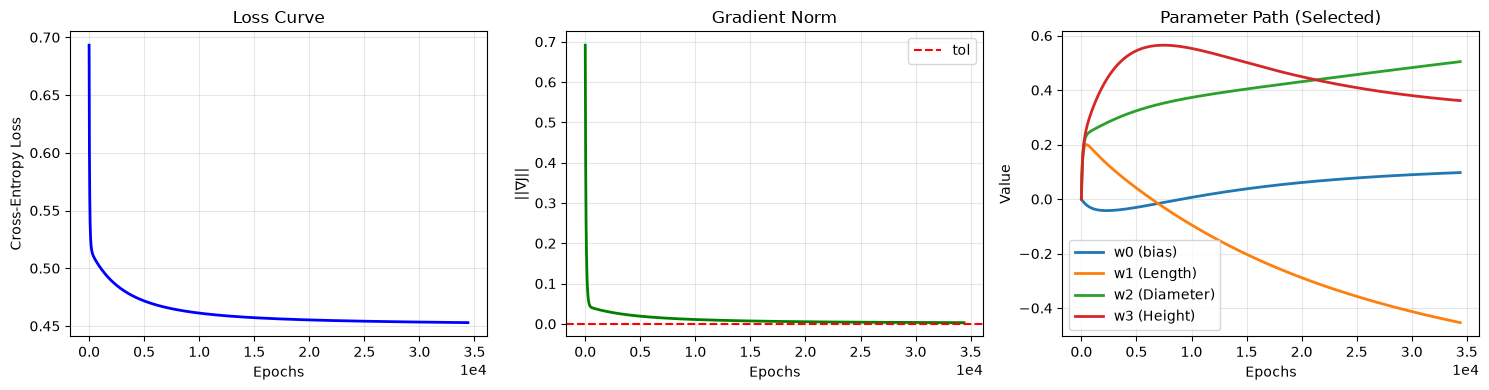

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# 超参数
W_init = np.zeros(8)    # 偏置项b + 7个特征，初始权重全为零
lr = 0.01               # 学习率
tol = 1e-7              # 容差
max_epochs = 1000000    # 最大迭代次数
# 载入训练集
out_dir = './outputs/lr'
df_train = pd.read_csv(f'{out_dir}/abalone_train.csv')
features = ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight']
# 构建特征矩阵（添加偏置列）
X_train_raw = df_train[features].values
# 数据标准化
mu = np.mean(X_train_raw, axis=0)
sigma = np.std(X_train_raw, axis=0)
sigma[sigma == 0] = 1
X_train_std = (X_train_raw - mu) / sigma
# 添加偏置列
X_train = np.c_[np.ones((X_train_std.shape[0], 1)), X_train_std]    # 左侧加全1列
# 目标变量，二分类标签：Adult=1, Juvenile=0
y_train = df_train['Adult'].values
# Sigmoid 函数
def sigmoid(z):
    z = np.clip(z, -500, 500)   # 限制在 [-500, 500] , 防止溢出
    return 1 / (1 + np.exp(-z))
# 代价函数
def cost_func(W, X, Y):
    z = X @ W
    Y_hat = sigmoid(z)
    # 把概率限制在 0.000...001 到 0.999...999 之间，避免出现 log(0) 或 log(1)
    Y_hat = np.clip(Y_hat, 1e-15, 1 - 1e-15)
    return -np.mean(Y * np.log(Y_hat) + (1 - Y) * np.log(1 - Y_hat))
# GD 函数
def gradient_descent(X, Y, W_init, lr, max_epochs, tol):
    W = W_init.copy()
    n = len(X)  # 样本数
    # 记录历史数据
    W_hist = [W.copy()]
    cost_hist = [cost_func(W, X, Y)]
    grad_hist = []
    param_hist = []
    # 循环进行梯度下降
    for epoch in range(max_epochs):
        Y_hat = sigmoid(X @ W)          # 预测
        error = Y_hat - Y               # 残差
        dW = (1/n) * X.T @ error        # 平均梯度
        grad_norm = np.linalg.norm(dW)  # 梯度范数
        grad_hist.append(grad_norm)
        # 停止条件1：梯度范数小于容差
        if grad_norm < tol:
            print(f"✅ 停止于梯度容差：第 {epoch} 轮，梯度范数 = {grad_norm:.2e} < {tol}")
            break
        # 更新参数、代价，并保存
        W_new = W - lr * dW     # 更新参数
        param_change = np.linalg.norm(W_new - W)    # 参数变化量
        param_hist.append(param_change)
        cost_new = cost_func(W_new, X, Y)   # 计算新的代价值
        W = W_new
        W_hist.append(W.copy())
        cost_hist.append(cost_new)
        # 停止条件2：参数变化量小于容差
        if param_change < tol:
            print(f"✅ 停止于参数变化容差：第 {epoch} 轮，参数变化 = {param_change:.2e} < {tol}")
            break
        # 停止条件3：代价变化量小于容差
        if abs(cost_hist[-1] - cost_hist[-2]) < tol:
            print(f"✅ 停止于代价变化容差：第 {epoch} 轮，代价变化 = {abs(cost_hist[-1] - cost_hist[-2]):.2e} < {tol}")
            break
    else:
        print(f"⚠️ 达到最大迭代次数 {max_epochs}，算法未完全收敛，请考虑调整参数。")
    # 返回数据
    return {
        'epochs': len(W_hist),
        'W_hist': W_hist,
        'cost_hist': cost_hist,
        'grad_hist': grad_hist,
        'param_hist': param_hist
    }
# 运行梯度下降
history = gradient_descent(X_train, y_train, W_init, lr, max_epochs, tol)
# 绘制三个监测图
epochs = history['epochs']
W_hist = history['W_hist']
cost_hist = history['cost_hist']
grad_hist = history['grad_hist']
param_hist = history['param_hist']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# 图1：损失下降曲线
axes[0].plot(range(epochs), cost_hist, color='blue', lw=2)
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)
# 图2：梯度范数变化
axes[1].plot(range(len(grad_hist)), grad_hist, color='green', lw=2)
axes[1].axhline(y=tol, color='red', linestyle='--', label='tol')
axes[1].set_title('Gradient Norm')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('||∇J||')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
# 图3：参数轨迹（取前四个）
W_array = np.array(W_hist)
axes[2].plot(range(epochs), W_array[:, 0], label='w0 (bias)', lw=2)
axes[2].plot(range(epochs), W_array[:, 1], label='w1 (Length)', lw=2)
axes[2].plot(range(epochs), W_array[:, 2], label='w2 (Diameter)', lw=2)
axes[2].plot(range(epochs), W_array[:, 3], label='w3 (Height)', lw=2)
axes[2].set_title('Parameter Path (Selected)')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Value')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
# 强制 X 轴刻度使用科学计数法（如 1e5, 2e5），防止数值过大时标签重叠
for ax in axes:
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.tight_layout()
plt.savefig(f'{out_dir}/gd_mlr_monitor.png', dpi=150)
# 训练结果
W_final = W_hist[-1]
print("\n训练完成，拟合方程系数：")
print(f"  bias (intercept) : {W_final[0]:.6f}")
for name, coef in zip(features, W_final[1:]):
    print(f"  {name:20s} : {coef:.6f}")
print(f"\nFinal cost J = {cost_hist[-1]:.6f}, total epochs = {epochs}")
# 在测试集用训练好的模型预测，并评估结果
df_test = pd.read_csv(f'{out_dir}/abalone_test.csv')
X_test_raw = df_test[features].values
# 数据标准化（在测试验证时要用训练集算出来的均值和标准差，因为模拟的是未来未知的新数据）
X_test_std = (X_test_raw - mu) / sigma
# 添加偏置列
X_test = np.c_[np.ones((X_test_std.shape[0], 1)), X_test_std]
y_test = df_test['Adult'].values
Y_hat = sigmoid(X_test @ W_final)   # 预测概率
Y_pred = (Y_hat >= 0.5).astype(int) # 预测类别
# 分类评估指标
accuracy = accuracy_score(y_test, Y_pred)
precision = precision_score(y_test, Y_pred)
recall = recall_score(y_test, Y_pred)
f1 = f1_score(y_test, Y_pred)
conf_mat = confusion_matrix(y_test, Y_pred)
df_cm = pd.DataFrame(
    conf_mat,
    index=['Actual Juvenile', 'Actual Adult'],
    columns=['Predicted Juvenile', 'Predicted Adult']
)
print("\n========== 测试集评估结果 ==========")
print(f"准确率 (Accuracy)  : {accuracy:.4f}")
print(f"精确率 (Precision) : {precision:.4f}")
print(f"召回率 (Recall)    : {recall:.4f}")
print(f"F1-score           : {f1:.4f}")
print("混淆矩阵 (Confusion Matrix):")
print(df_cm)
print("====================================")
plt.show()

## 11 sklearn LR

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ========== 使用 sklearn 训练逻辑回归 ==========
model = LogisticRegression(
    C=np.inf,                # 关闭正则化（替代 penalty=None）
    solver='lbfgs',          # 拟牛顿法求解器
    max_iter=10000,          # 最大迭代次数
    tol=1e-7                 # 容差
)
model.fit(X_train_std, y_train)     # X_train_std 是标准化后的特征（无偏置列）
y_pred = model.predict(X_test_std)  # 预测类别
# 计算分类指标
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_mat = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(
    conf_mat,
    index=['Actual Juvenile', 'Actual Adult'],
    columns=['Predicted Juvenile', 'Predicted Adult']
)
print("\n========== sklearn 测试集评估结果 ==========")
print(f"准确率 (Accuracy)  : {accuracy:.4f}")
print(f"精确率 (Precision) : {precision:.4f}")
print(f"召回率 (Recall)    : {recall:.4f}")
print(f"F1-score           : {f1:.4f}")
print("混淆矩阵 (Confusion Matrix):")
print(df_cm)
print("============================================")


========== sklearn 测试集评估结果 ==========
准确率 (Accuracy)  : 0.7775
精确率 (Precision) : 0.8039
召回率 (Recall)    : 0.7558
F1-score           : 0.7791
混淆矩阵 (Confusion Matrix):
                 Predicted Juvenile  Predicted Adult
Actual Juvenile                 322               80
Actual Adult                    106              328


## 附：手写 LR vs sklearn LR

评估指标：

| 评估指标 | 手写 LR | sklearn LR | 差值 (手写 - sklearn) |
| :--- | :---: | :---: | :---: |
| **准确率 (Accuracy)** | 0.7835 | 0.7775 | **+0.0060** |
| **精确率 (Precision)** | 0.8005 | 0.8039 | -0.0034 |
| **召回率 (Recall)** | 0.7765 | 0.7558 | **+0.0207** |
| **F1-score** | 0.7883 | 0.7791 | **+0.0092** |

混淆矩阵：

| 混淆矩阵 | 预测：未成年 (0) | 预测：成年 (1) |
| :--- | :---: | :---: |
| **手写 LR — 真实：未成年 (0)** | 318 | 84 |
| **手写 LR — 真实：成年 (1)** | 97 | 337 |
| **sklearn LR — 真实：未成年 (0)** | 322 | 80 |
| **sklearn LR — 真实：成年 (1)** | 106 | 328 |

小结：
- 手写 LR 的准确率、召回率、F1 均略高于 sklearn，差异在 1~2% 以内。
- sklearn 的精确率略高（误报更少），但 召回率 较低（漏报更多）。
- 两者整体非常接近，差异主要来自优化算法的不同：手写代码使用批量梯度下降，sklearn 使用 L-BFGS 拟牛顿法，收敛路径不同导致最终落点略有差异。